In [24]:
%matplotlib inline


# Réseaux récurrents pour la classification de texte
D'après le tutoriel de
**Author**: [Sean Robertson](https://github.com/spro/practical-pytorch)

Reformulé pour le Master SID Université de Rouen Normandie, module Deep Learning, Thierry Paquet, 2023.

Nous construisons un réseau récurrent chargé de classer l'origine des noms de famille. Le dataset est constitué d'un ensemble de noms de famille Européens. Le réseau parcourt un nom de gauche à droite, caractère par caractère, et utilise son état interne à la fin du parcours pour classer le nom parmi 18 langues possibles.
Voici deux exemples de prédiction: 
    $ python predict.py Hinton
    (-0.47) Scottish
    (-1.52) English
    (-3.57) Irish

    $ python predict.py Schmidhuber
    (-0.19) German
    (-2.48) Czech
    (-2.68) Dutch


## Preparation des données

Le fichier de prénoms est chargé à partir de ce lien 
   [https://download.pytorch.org/tutorial/data.zip](https://download.pytorch.org/tutorial/data.zip) et décompressé dans le répertoire courant.

Dans le répertoire ``data/names`` se trouvent 18 fichiers texte nommés 
"[Language].txt". Chaque fichier comprend un ensemble de noms, un par ligne, écrits avec des caractères Romains. Mais il subsiste des caractères spéciaux propres à certaines langues, que l'on va devoir normaliser. Une étape de pré-traitement est donc mise en oeuvre pour transformer les caractères UNICODE en ASCII.

Depuis votre machine locale, placer les 18 fichiers dans un répertoire ``data/names`` sous google drive. A l'intialisation de votre programme, vous crérez le répertoire drive puis monterez votre partition Drive dans votre environnement d'exécution Colab à l'aide des commandes ci-dessous.

## **Question 1:** Expliquez chaque étape de la méthode ```unicodeToAscii()```**

In [25]:
from google.colab import drive
!mkdir -p drive
drive.mount('/content/drive',force_remount=True)
#!ls drive/MyDrive/data/names

Mounted at /content/drive


In [26]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os
import unicodedata
import string

def findFiles(path): return glob.glob(path)

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print('Ślusàrski ToAscii',unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles('drive/MyDrive/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

Ślusàrski ToAscii Slusarski


A present nous avons dans la variable ``category_lines``,  un dictionnaire des noms des langues qui permet d'accéder au listes de noms de chaque langue. On mémorise également dans la variable  ``all_categories`` la liste des noms des langues et dans ``n_categories`` le nombre de langues.




In [27]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


### Transformation en tenseurs

Il faut maintenant écrire les données dans des tenseurs. Chaque caractère va être encodé en un vecteur binaire dit "one-hot vector" de taille 
$<1 \times n_{letters}>$. Un vecteur one-hot est un vecteur binaire rempli de valeurs à 0 à l'exception d'une seule entrée mise à 1 correspondant à l'index du caractère représenté par ce vecteur, par exemple ``"b" = <0 1 0 0 0 ...>``.

Un mot est donc encodé par une séquence de vecteurs one-hot qui est placée dans un tenseur 2D de dimension $<line\_length \times 1 \times n_{letters}>$.

On insère une dimension suplémentaire de taille 1 parce que PyTorch manipule des lots (batch) - ici nous avons donc un batch de taille 1 exemple.


In [28]:
import torch

# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor
print('One hot vector de la lettre J:')
print(letterToTensor('J'))

print('Taille du tenseur encodant le mot "Jones":')
print(lineToTensor('Jones').size())

One hot vector de la lettre J:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
Taille du tenseur encodant le mot "Jones":
torch.Size([5, 1, 57])


## Creation de la classe réseau récurrent
Avant l'utilisation par Pytorch de l'autodifférentiation par la méthode  ``` autograd```, la création d'un réseau récurrent passait par la déclaration d'une couche qui se répétait sur plusieurs pas de temps consécutifs. Ces couches maintenaient l'état caché et le gradient rétropropagé au cours du temps.

Désormais, les couches récurrentes sont gérées par ```autograd``` qui construit pour nous le graphe de calcul du réseau déplié au cours du temps. Cela veut dire qu'un réseau récurrent est désormais déclaré comme un réseau feed-forward non récurrent, et que c'est autograd qui gère la structure récurrente lorsque le réseaux est instancié.

Le réseau récurrent que nous allons utiliser contient simplement deux couches `Linear()` qui voient toutes deux les données d'entrée constituées de l'entrée courante + la sortie précédente concaténées ```combined = torch.cat()```.

La première couche linéaire est de type feedforward suivie d'une activation softmax. Elle produit la sortie courante. 
La seconde couche est récurrente. Elle produit l'état caché de la couche récurrente à travers une couche linéaire. L'ensemble est schématisé sur cette figure: <img src="https://i.imgur.com/Z2xbySO.png"></img>


In [29]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

Pour faire une itération avec ce réseau il faut lui fournir une entrée (dans notre cas le one-hot vector qui encode le caractère courant et l'état précédent du réseau (initialisé à zéro à la première itération). 
Le réseau fournit en retour le vecteur de probabilité de chaque langue et l'état caché courant (que l'on va utiliser pour l'itération suivante).

In [30]:
input = letterToTensor('A')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input, hidden)

Pour être plus efficace on ne crée pas un nouveau tenseur pour chaque nouveau caractère d'entrée. 
A la place, on crée un seul tenseur pour toute la séquence de caractères. On utilise  `` input = lineToTensor`` au lieu de ``letterToTensor`` et on itère sur toutes les positions du tenseur de la séquence d'entrée. 

## **Question 2:** Expliquez chaque étape de la méthode ```lineToTensor()``` 

## **Question 3:** Que représente le tenseur ```output``` ?

In [31]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
# print(output)

## Entrainement du réseau
Préparer l'entrainement
----------------------

On déclare quelques fonctions qui vont nous aider. La première va nous permettre de mieux visualiser la sortie courante du réseau. On utilise pour cela la méthode ``categoryFromOutput()``.

## **Question 4:** Expliquez chaque ligne de la méthode ``categoryFromOutput()``

In [32]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

# print(categoryFromOutput(output))

On a également besoin de visualiser un exemple d'apprentissage (un nom et sa langue).

## **Question 5:** Que réalise la fonction ``` randomTrainingExample()``` ?


In [33]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    # print('category =', category, '/ line =', line)

### Entrainer le réseau

Maintenant il suffit de présenter au réseau un lot d'apprentissage pour qu'il fasse une prédiction et qu'il adapte ses poids en fonction de ses erreurs.
Puisque la fonction d'activation de sortie est une `nn.LogSoftmax`, le critère d'apprentissage choisi est  `nn.NLLLoss`.


## **Question 6:** A quoi correspond le critère pytorch `nn.NLLLoss` ?

In [34]:
criterion = nn.NLLLoss()

Chaque époque de la boucle d'apprentissage fait appel à la méthode `train()`

## **Question 7:** expliquez toutes les étapes de la méthode `train()` 
Préciser
- la taille des lots
- l'optimiseur utilisé

Proposez quelques améliorations possibles de cette méthode

In [36]:
learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden()

    rnn.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

Maintenant il suffit simplement de lancer l'exécution de l'apprentissage sur l'ensemble des exemples. 

## **Question 8 :** expliquer la structure de la boucle principale du programme
Précisez notamment les variables mémorisées et visualisées

In [37]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000


# Keep track of losses for plotting
current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    # Print iter number, loss, name and guess
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 7s) 2.7390 Acquarone / Greek ✗ (Italian)
10000 10% (0m 13s) 3.0321 Kaluza / Japanese ✗ (Polish)
15000 15% (0m 24s) 1.2388 Cen / Vietnamese ✗ (Chinese)
20000 20% (0m 37s) 1.4178 Mifsud / Arabic ✓
25000 25% (0m 43s) 2.0245 Cabral / French ✗ (Portuguese)
30000 30% (0m 51s) 1.3117 Sauvage / French ✓
35000 35% (0m 57s) 0.4804 Chin / Korean ✓
40000 40% (1m 5s) 0.4994 Sedmikova / Czech ✓
45000 45% (1m 11s) 3.4357 Samson / Arabic ✗ (Dutch)
50000 50% (1m 18s) 1.4752 Ondrisek / Czech ✓
55000 55% (1m 25s) 2.5246 Guirguis / Portuguese ✗ (Arabic)
60000 60% (1m 32s) 1.1936 Chang / Chinese ✗ (Korean)
65000 65% (1m 39s) 1.1660 Filipek / Polish ✓
70000 70% (1m 47s) 2.2487 Ramos / Greek ✗ (Spanish)
75000 75% (1m 53s) 0.3759 Arian / Arabic ✓
80000 80% (2m 1s) 2.8863 Koci / Italian ✗ (Czech)
85000 85% (2m 8s) 0.7364 Vinh / Vietnamese ✓
90000 90% (2m 16s) 0.6719 Finogeev / Russian ✓
95000 95% (2m 22s) 0.9897 Kwang  / Korean ✓
100000 100% (2m 30s) 0.1257 Mulryan / Irish ✓


### Affichage des résultats

On visualise l'évolution du critère ``all_losses`` au cours de l'apprentissage:


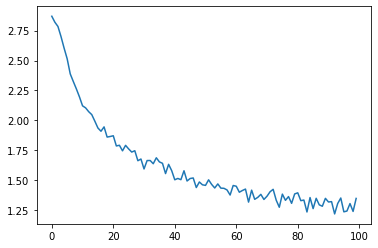

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

## Evaluation des performances
Pour une première évaluation des capacités du réseau on calcule la matrice de confusion. 

## **Question 9:** Préciser le rôle de la fonction `evaluate()`

## **Question 10:** Quel est le principal défaut de cette évaluation ?

## **Question 11:** Quelles sont les langues les moins bien identifiées? Quelles sont les principales confusions ? 

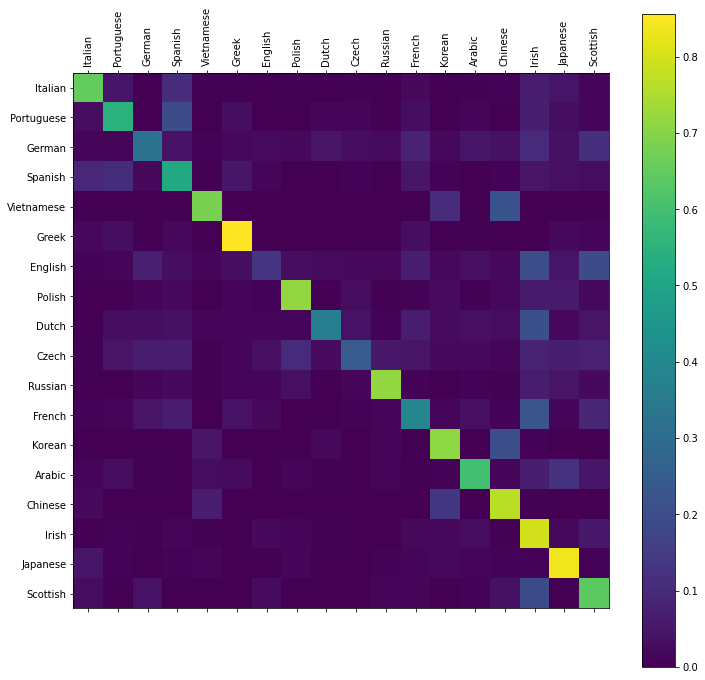

In [40]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

# Just return an output given a line
def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Set up plot
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

### Exécution sur vos prropres exemples

## **Question 12:** Expliquer les différentes étapes de la méthode `predict()`

In [41]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line))

        # Get top N categories
        topv, topi = output.topk(n_predictions, dim=1, largest=True)
        # largest: controls whether to return largest or smallest elements
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Dovesky')
predict('Jackson')
predict('Satoshi')


> Dovesky
(-0.15) Russian
(-2.70) Czech
(-3.88) English

> Jackson
(-0.09) Scottish
(-3.31) English
(-3.71) Russian

> Satoshi
(-1.11) Japanese
(-1.29) Arabic
(-2.27) Italian


## Exercices supplémentaires

-  Améliorer les résultats en envisageant une évolution de l'architecture du réseau

   -  ajouter plus de couches linéaires
   -  empiler  plusieurs couches récurrentes
   
-  Extensions possibles : envisager d'autres tâches similaires telles que:
   -  Déduire le genre des prénoms
   -  Classer des lignes de texte parmi Titre / plein texte / légende etc... 

